In [ ]:
# Load cleaned dataset from CSV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any

df_cleaned = pd.read_csv('/Users/mgarzon/Desktop/Statistics/FinalProject/ai-masters-stats-probability/Untitled/notebooks/df_cleaned.csv')

# Verify the dataset loaded
print("✓ Cleaned dataset loaded successfully")
print(f"Shape: {df_cleaned.shape}")
print(f"Columns: {df_cleaned.columns.tolist()}")

✓ Cleaned dataset loaded successfully
Shape: (41432, 14)
Columns: ['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'income_binary']


2. ANALYSIS - AGE

Age Statistics:
  Mean: 39.44
  Median: 38.00
  Std: 13.64
  Min: 17.00
  Max: 90.00
  Q25: 29.00
  Q75: 49.00


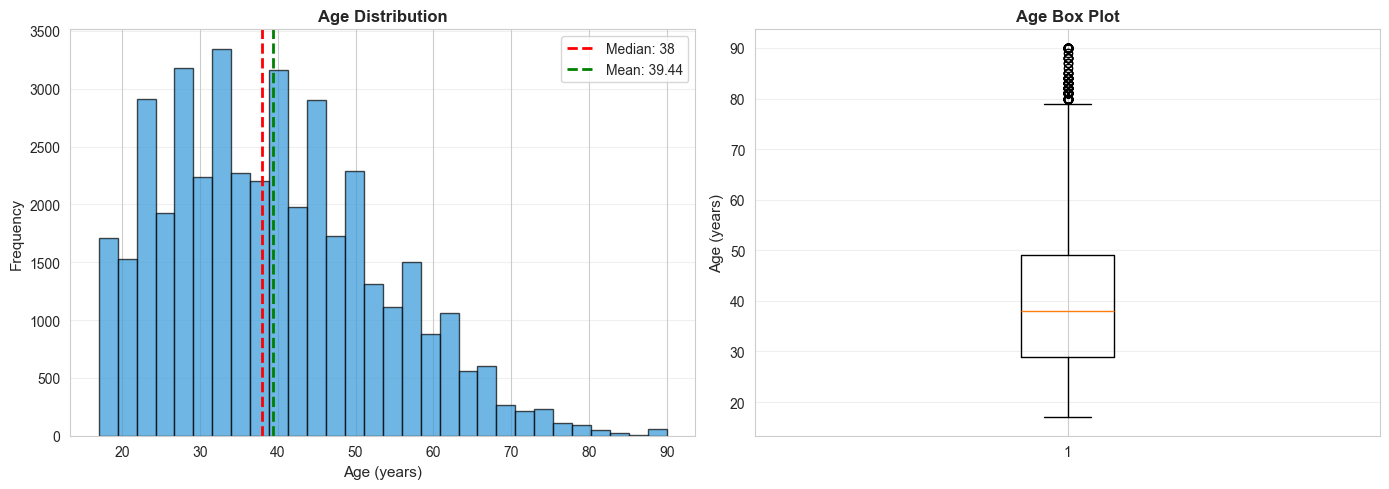

In [ ]:
# Function 1:Analysis - Age
def analyze_age(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze age distribution."""
    
    print("2. ANALYSIS - AGE")

    age_stats = {
        'mean': df['age'].mean(),
        'median': df['age'].median(),
        'std': df['age'].std(),
        'min': df['age'].min(),
        'max': df['age'].max(),
        'q25': df['age'].quantile(0.25),
        'q75': df['age'].quantile(0.75)
    }
    
    print(f"\nAge Statistics:")
    for key, value in age_stats.items():
        print(f"  {key.capitalize()}: {value:.2f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df['age'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].axvline(age_stats['median'], color='red', linestyle='--', linewidth=2, 
                    label=f"Median: {age_stats['median']:.0f}")
    axes[0].axvline(age_stats['mean'], color='green', linestyle='--', linewidth=2, 
                    label=f"Mean: {age_stats['mean']:.2f}")
    axes[0].set_xlabel('Age (years)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Box plot
    axes[1].boxplot(df['age'], vert=True)
    axes[1].set_ylabel('Age (years)', fontsize=11)
    axes[1].set_title('Age Box Plot', fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return age_stats

age_stats = analyze_age(df_cleaned)


2. ANALYSIS - GENDER

Gender Distribution:
  Male: 27,382 (66.09%)
  Female: 14,050 (33.91%)


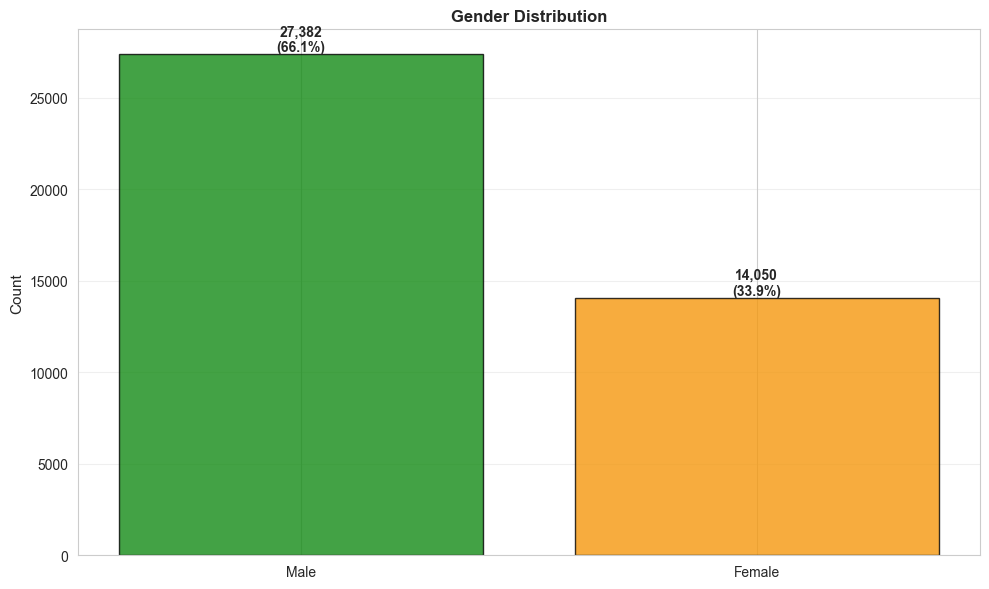

In [37]:
# function 2:Analysis - Gender
def analyze_gender(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze gender distribution."""
    print("2. ANALYSIS - GENDER")

    gender_dist = df['sex'].value_counts()
    gender_pct = df['sex'].value_counts(normalize=True) * 100
    
    print(f"\nGender Distribution:")
    for gender in gender_dist.index:
        count = gender_dist[gender]
        pct = gender_pct[gender]
        print(f"  {gender}: {count:,} ({pct:.2f}%)")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ["#148b16", "#f5980e"]
    bars = ax.bar(gender_dist.index, gender_dist.values, color=colors, 
                   edgecolor='black', alpha=0.8)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Gender Distribution', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return gender_dist.to_dict()

gender_dist = analyze_gender(df_cleaned)


2. ANALYSIS - EDUCATION

Education Distribution:
  Total education levels: 16


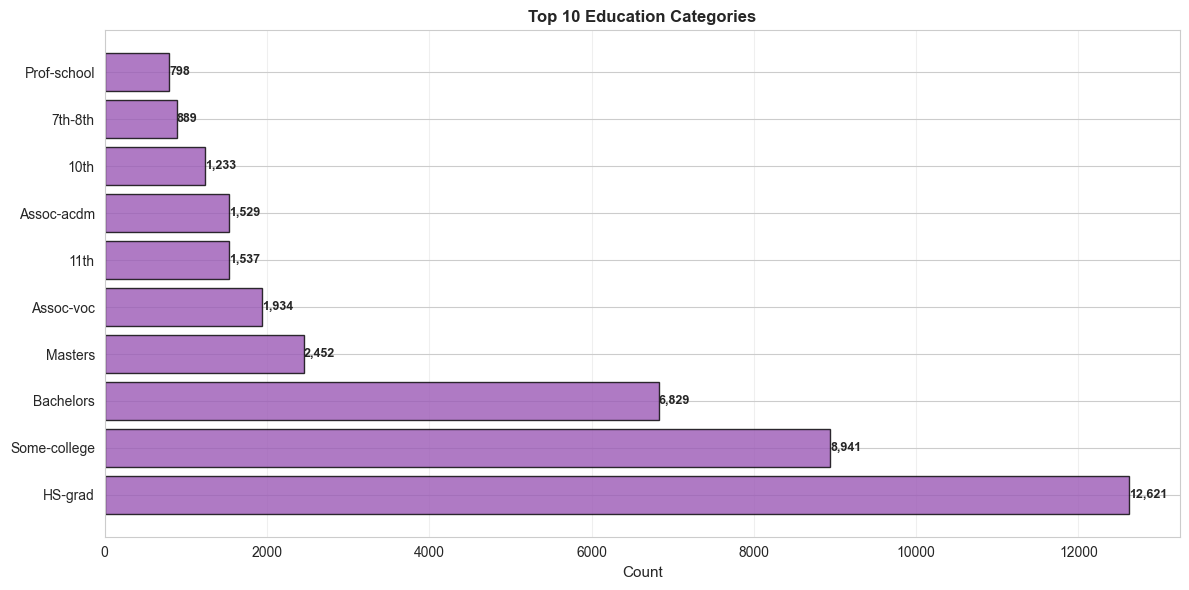

In [30]:
# Funtion 3: Analysis - Education
def analyze_education(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze education distribution."""

    print("\n2. ANALYSIS - EDUCATION")
    
    edu_dist = df['education'].value_counts()
    
    print(f"\nEducation Distribution:")
    print(f"  Total education levels: {df['education'].nunique()}")
    
    # Visualization - Top 10 only
    fig, ax = plt.subplots(figsize=(12, 6))
    top_10_edu = edu_dist.head(10)
    bars = ax.barh(range(len(top_10_edu)), top_10_edu.values, color='#9b59b6', 
                   edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(top_10_edu)))
    ax.set_yticklabels(top_10_edu.index)
    ax.set_xlabel('Count', fontsize=11)
    ax.set_title('Top 10 Education Categories', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f'{int(width):,}',
                ha='left', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return edu_dist.to_dict()

edu_dist = analyze_education(df_cleaned)



ANALYSIS - INCOME

Income Distribution:
  ≤$50K (Budget): 31,127 (75.13%)
  >$50K (Premium): 10,305 (24.87%)


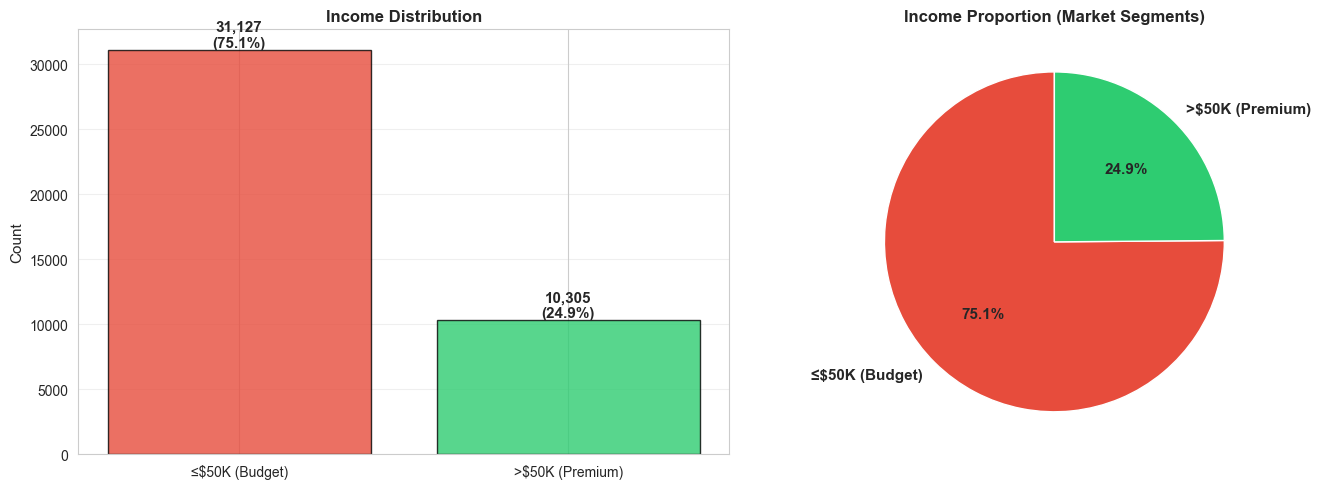

In [ ]:
# Function 4: Analysis - Income
def analyze_income(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze income distribution."""
    print("\nANALYSIS - INCOME")
    
    income_counts = df['income_binary'].value_counts()
    income_labels = {0: '≤$50K (Budget)', 1: '>$50K (Premium)'}
    
    print(f"\nIncome Distribution:")
    for category, count in income_counts.items():
        label = income_labels[category]
        pct = count / len(df) * 100
        print(f"  {label}: {count:,} ({pct:.2f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    colors = ['#e74c3c', '#2ecc71']
    labels = [income_labels[i] for i in income_counts.index]
    bars = axes[0].bar(labels, income_counts.values, color=colors, 
                       edgecolor='black', alpha=0.8)
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_title('Income Distribution', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Pie chart
    axes[1].pie(income_counts.values, labels=labels, autopct='%1.1f%%',
                colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[1].set_title('Income Proportion (Market Segments)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return income_counts.to_dict()

income_dist = analyze_income(df_cleaned)

3. BIVARIATE ANALYSIS - INCOME by GENDER

Income Distribution by Gender (Counts):
sex            Female   Male
income_binary               
0               12359  18768
1                1691   8614

Income Distribution by Gender (Percentages):

≤$50K (Budget):
  • Female: 39.7% (12,359)
  • Male: 60.3% (18,768)

>$50K (Premium):
  • Female: 16.4% (1,691)
  • Male: 83.6% (8,614)


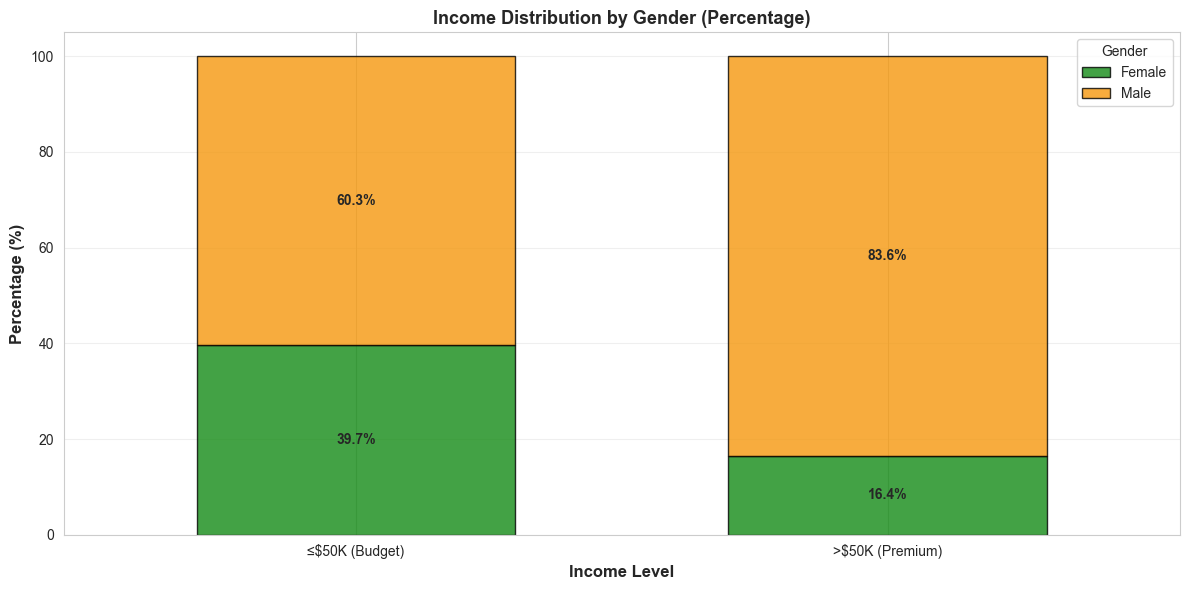

In [ ]:
# Anlysis: Income by Gender (Percentages)
print("ANALYSIS - INCOME by GENDER")
# Calculate gender distribution within each income group
income_gender_crosstab = pd.crosstab(df_cleaned['income_binary'], df_cleaned['sex'], margins=False)
income_gender_pct = pd.crosstab(df_cleaned['income_binary'], df_cleaned['sex'], normalize='index') * 100

# Create labels for income categories
income_labels = {0: '≤$50K (Budget)', 1: '>$50K (Premium)'}

print("\nIncome Distribution by Gender (Counts):")
print(income_gender_crosstab)

print("\nIncome Distribution by Gender (Percentages):")
for income_cat in [0, 1]:
    label = income_labels[income_cat]
    print(f"\n{label}:")
    for gender in income_gender_pct.columns:
        pct = income_gender_pct.loc[income_cat, gender]
        count = income_gender_crosstab.loc[income_cat, gender]
        print(f"  • {gender}: {pct:.1f}% ({count:,})")

# Visualization - Stacked percentage bar chart
fig, ax = plt.subplots(figsize=(12, 6))

income_gender_pct_plot = income_gender_pct.copy()
income_gender_pct_plot.index = [income_labels[i] for i in income_gender_pct_plot.index]
income_gender_pct_plot.plot(
    ax=ax,
    kind='bar',
    stacked=True,
    color=['#148b16', '#f5980e'],
    edgecolor='black',
    alpha=0.8,
    width=0.6
)

ax.set_xlabel('Income Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Income Distribution by Gender (Percentage)', fontsize=13, fontweight='bold')
ax.legend(title='Gender', loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

ANALYSIS - INCOME by EDUCATION 

 Income Distribution by Education Group:
education_group  Bachelor's+  HS Graduate  Less than HS  Some College
income                                                               
<=50K                   17.7         33.8          17.4          31.1
>50K                    49.7         20.4           3.4          26.5


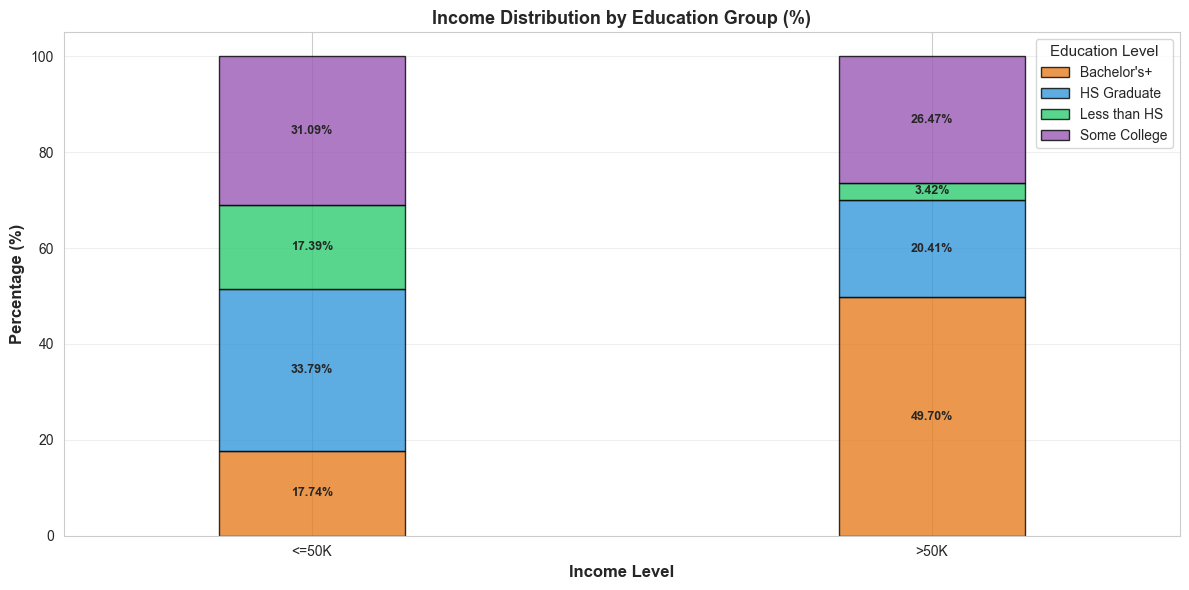

In [59]:
# CELL 7: Visualize Income by Education - PERCENTAGES (4 Groups)
""" How does EDUCATION affect INCOME?
Education grouped into 4 levels:
1. Less than High School (No degree)
2. High School Graduate
3. Some College/Associates
4. Bachelor's Degree or Higher (Advanced)

Why this grouping:
- Simplifies 16 education categories into meanngful segments
- Easier to see clear patterns
- Better for business decision-making
"""
# Group education into 4 categories
def categorize_education(edu):
    """Simplify education levels into 4 meaningful groups."""
    less_than_hs = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    hs_grad = ['HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors_plus = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']
    
    if edu in less_than_hs:
        return 'Less than HS'
    elif edu in hs_grad:
        return 'HS Graduate'
    elif edu in some_college:
        return 'Some College'
    else:
        return "Bachelor's+"
    
print("ANALYSIS - INCOME by EDUCATION ")
# Create new education group column
df_cleaned['education_group'] = df_cleaned['education'].apply(categorize_education)

# Calculate percentages
edu_group_pct = pd.crosstab(df_cleaned['income'], df_cleaned['education_group'], normalize='index') * 100

print("\n Income Distribution by Education Group:")
print(edu_group_pct.round(1))

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

edu_group_pct.plot(
    ax=ax,
    kind='bar',
    stacked=True,
    color=['#e67e22', '#3498db', '#2ecc71', '#9b59b6'],
    edgecolor='black',
    alpha=0.8,
    width=0.3
)

ax.set_xlabel('Income Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Income Distribution by Education Group (%)', fontsize=13, fontweight='bold')
ax.legend(title='Education Level', loc='upper right', fontsize=10, title_fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()